# Packages + Data load

In [37]:
import kagglehub
from dotenv import load_dotenv
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.special import inv_boxcox
import math

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.cross_decomposition import PLSRegression

In [20]:
from dotenv import load_dotenv
import os

# 1. Load variables from .env into the environment
load_dotenv() 

# 2. Access them using the standard OS library
kaggle_user = os.getenv('KAGGLE_USERNAME')
kaggle_key = os.getenv('KAGGLE_KEY')

# Download the latest version of the competition data
path = kagglehub.competition_download("house-prices-advanced-regression-techniques")

print("Path to competition files:", path)

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv(os.path.join(path, "train.csv"))
df_test = pd.read_csv(os.path.join(path, "test.csv"))

Path to competition files: C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques
C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques\data_description.txt
C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques\sample_submission.csv
C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques\test.csv
C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques\train.csv


In [21]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
df.info()
df.head()

Number of rows: 1460
Number of columns: 81
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [22]:
series = df.isna().sum().sort_values(ascending=False)
series[series > 0]

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [23]:
cat_cols=df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64']).columns
print("Categorical Variables:")
print(len(cat_cols))
print(cat_cols.values)
print("\n")
print("Numerical Variables:")
print(len(num_cols))
print(num_cols.values)

Categorical Variables:
43
<StringArray>
[     'MSZoning',        'Street',         'Alley',      'LotShape',
   'LandContour',     'Utilities',     'LotConfig',     'LandSlope',
  'Neighborhood',    'Condition1',    'Condition2',      'BldgType',
    'HouseStyle',     'RoofStyle',      'RoofMatl',   'Exterior1st',
   'Exterior2nd',    'MasVnrType',     'ExterQual',     'ExterCond',
    'Foundation',      'BsmtQual',      'BsmtCond',  'BsmtExposure',
  'BsmtFinType1',  'BsmtFinType2',       'Heating',     'HeatingQC',
    'CentralAir',    'Electrical',   'KitchenQual',    'Functional',
   'FireplaceQu',    'GarageType',  'GarageFinish',    'GarageQual',
    'GarageCond',    'PavedDrive',        'PoolQC',         'Fence',
   'MiscFeature',      'SaleType', 'SaleCondition']
Length: 43, dtype: str


Numerical Variables:
35
<StringArray>
[           'Id',    'MSSubClass',       'LotArea',   'OverallQual',
   'OverallCond',     'YearBuilt',  'YearRemodAdd',    'BsmtFinSF1',
    'BsmtFinSF2',

C:\Users\RobertMorsch\AppData\Local\Temp\ipykernel_26884\584291390.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include=['object']).columns


# Null Handling

In [24]:
# Columns where NA is intentional to mean "Absent"
na_means_absent_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu',
                         'GarageQual', 'GarageFinish', 'GarageType', 'GarageCond', 'BsmtFinType2', 'BsmtExposure', 
                         'BsmtCond', 'BsmtQual', 'BsmtFinType1']
# Columns where NA is likely missing data that should be  inferrable
# GarageYrBlt - likely can be inferred from GarageType or GarageFinish
# LotFrontage - NOT clear where it can be inferred, but null may just mean no frontage
# MasVnrArea - likely can be inferred from MasVnrType
# Electrical - Looks like may actually be true NA
na_means_missing_cols_but_inferrable = ['GarageYrBlt','LotFrontage', 'MasVnrArea']
# Columns where NA is likely missing data and needs imputation
na_means_missing_cols = ['Electrical']

print("NA Columns where NA means Absent:", len(na_means_absent_cols))
print("NA Columns where NA means Missing but Inferrable:", len(na_means_missing_cols_but_inferrable))
print("NA Columns where NA means Missing:", len(na_means_missing_cols))
na_series = df.isna().sum().sort_values(ascending=False)
len(series[series > 0]) == len(na_means_absent_cols) + len(na_means_missing_cols_but_inferrable) + len(na_means_missing_cols)

# Fill NA values after checking that NA missings for inferrables are in fact inferrable
for col in na_means_missing_cols_but_inferrable:
    if col == 'GarageYrBlt': # likely can be inferred from GarageType or GarageFinish, if GarageType is NA then it likely means no garage and thus GarageYrBlt should be 0
        df.loc[df['GarageType'].isna(), 'GarageYrBlt'] = 0
    elif col == 'LotFrontage': # doesnt appear to be inferrable, but null may just mean no frontage, may come back to this
        df.loc[df['LotFrontage'].isna(), 'LotFrontage'] = 0 
    elif col == 'MasVnrArea': # can be inferred from MasVnrType, if MasVnrType is NA then it likely means no masonry veneer and thus MasVnrArea should be 0
        df.loc[df['MasVnrType'].isna(), 'MasVnrArea'] = 0
df[na_means_missing_cols_but_inferrable].isna().sum().sort_values(ascending=False) # check that all NA values have been filled for the inferrable columns

# Fill NA values for columns where NA means Absent with "None"
for col in na_means_absent_cols:
    df[col] = df[col].fillna("None")
    df_test[col] = df_test[col].fillna("None")

# Fill NA values for columns where NA means Missing with the mode value
for col in na_means_missing_cols: 
    df[col] = df[col].fillna(df[col].mode()[0])

assert df.isna().sum().sum() == 0, f"There are still NA values in the dataframe after imputation \n {series[series > 0]}"

NA Columns where NA means Absent: 15
NA Columns where NA means Missing but Inferrable: 3
NA Columns where NA means Missing: 1


# Feature Engineering

In [25]:
df_ID = df['Id']
df.drop('Id', axis=1, inplace=True)
df['MSSubClass'] = df['MSSubClass'].astype(str)

df['YearBuilt_AGE'] = df['YrSold'] - df['YearBuilt']
df['YearReMod_AGE'] = df['YrSold'] - df['YearRemodAdd']
df['GarageYrBlt_AGE'] = df['YrSold'] - df['GarageYrBlt']

df['WasReModded'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)

In [26]:
# Dummy fields for nominal categorical columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

In [27]:
df_encoded.shape

(1460, 264)

# Model Functions

In [28]:
def convert_to_dollars(y_preds, lam = None, run=0):
    if run == 0:
        return y_preds
    else:
        return inv_boxcox(y_preds, lam)

# Split, Scaling, boxcox

In [29]:
#
# Check skewness before and after
print(f"Original skewness: {df['SalePrice'].skew():.4f}")

transformed_sale_price, lam = stats.boxcox(df['SalePrice'])
print(f"Transformed skewness: {pd.Series(transformed_sale_price).skew():.4f}")

Original skewness: 1.8829
Transformed skewness: -0.0087


In [30]:
# Train test split and feature scaling
y_original = df['SalePrice'] # keep original untransformed target for later use in evaluating model performance in dollars
Y = pd.Series(df['SalePrice'])
X = df_encoded.drop('SalePrice', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

_, _, y_train_original, y_test_original = train_test_split(X, y_original, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models

## OLS

In [31]:
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)
y_preds = ols_model.predict(X_test_scaled)
r_squared_score = ols_model.score(X_test_scaled, y_test)

# Inverse transform back to dollar scale
ols_preds_dollars = convert_to_dollars(y_preds, lam, 0)
mse = mean_squared_error(y_test_original, ols_preds_dollars)
print(f"Mean Squared Error: {mse}")
ols_rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {ols_rmse}")
print(f"R-squared score: {r_squared_score}")
print(f"Intercept: {ols_model.intercept_}")

Mean Squared Error: 6739826221.505192
Root Mean Squared Error: 82096.44463376713
R-squared score: 0.034145075660611646
Intercept: 181312.69275929563


# LassoCv

c:\Users\RobertMorsch\Practice_Projects\Ames-House-Prices\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.636e+09, tolerance: 5.306e+08
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\RobertMorsch\Practice_Projects\Ames-House-Prices\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.016e+10, tolerance: 5.306e+08
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\RobertMorsch\Practice_Projects\Ames-House-Prices\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase th

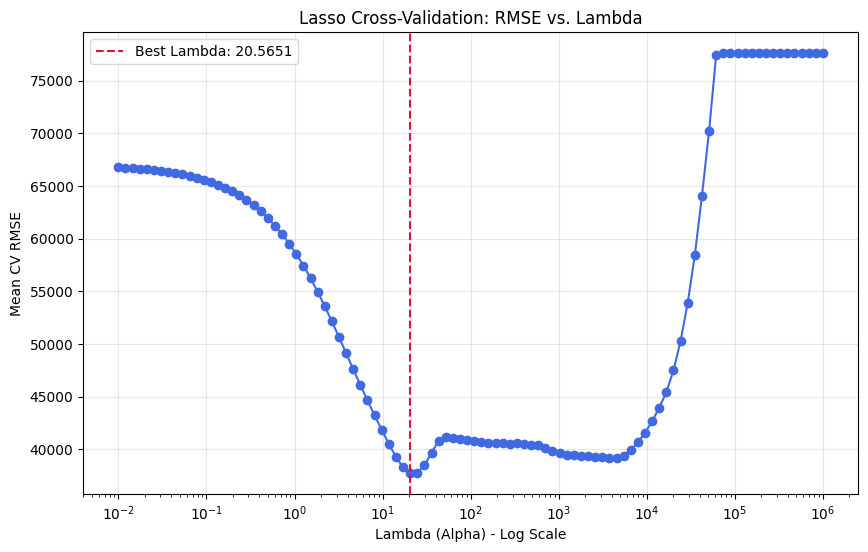

Optimal Lambda: 20.565123083486537
Final Test RMSE: 32992.5927


In [32]:
# Fit LassoCV
# cv=5 is standard; it tests a grid of alphas (lambdas) automatically
alphas = np.logspace(-2, 6, 100)
lcv_model = LassoCV(cv=10, alphas=alphas, random_state=42).fit(X_train_scaled, y_train)

# Extract RMSE Path
# model.mse_path_ stores MSE for each fold (n_alphas, n_folds)
# We average across folds and take the square root for RMSE
mean_mse = np.mean(lcv_model.mse_path_, axis=1)
rmse_path = np.sqrt(mean_mse)
alphas = lcv_model.alphas_

# Visualization the RMSE path across different lambdas
plt.figure(figsize=(10, 6))
plt.plot(alphas, rmse_path, marker='o', linestyle='-', color='royalblue')
plt.axvline(lcv_model.alpha_, color='crimson', linestyle='--', label=f'Best Lambda: {lcv_model.alpha_:.4f}')

plt.xlabel('Lambda (Alpha) - Log Scale')
plt.ylabel('Mean CV RMSE')
plt.title('Lasso Cross-Validation: RMSE vs. Lambda')
plt.xscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal Lambda: {lcv_model.alpha_}")
y_preds = lcv_model.predict(X_test_scaled)
# Inverse transform back to dollar scale
lcv_preds_dollars = convert_to_dollars(y_preds, lam, 0)
lasso_rmse = np.sqrt(mean_squared_error(y_test_original, lcv_preds_dollars))
print(f"Final Test RMSE: {lasso_rmse:.4f}")

# RidgeCV

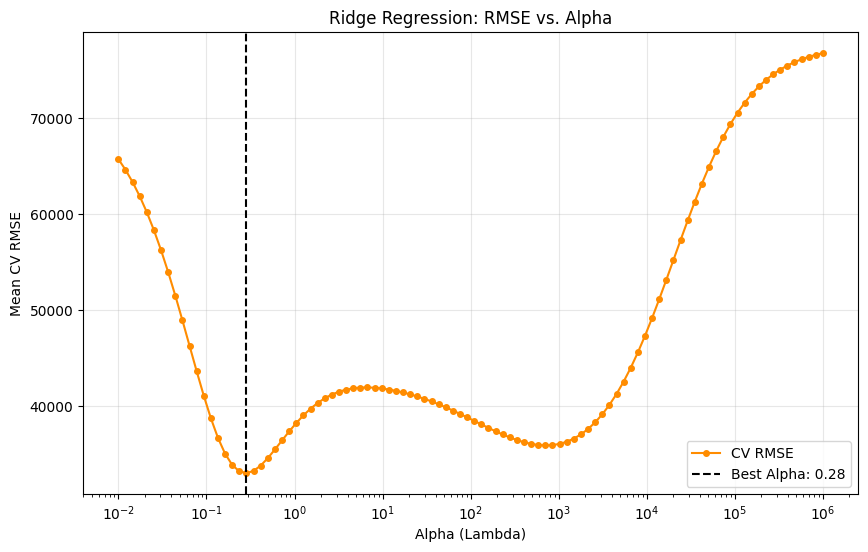

Optimal Alpha: 0.2848
Test RMSE at optimal: 36111.1962


In [33]:
# Define Alphas (lambdas) and fit RidgeCV
# store_cv_values=True is required to access the error path later
alphas = np.logspace(-2, 6, 100)
rcv_model = RidgeCV(alphas=alphas, store_cv_results=True).fit(X_train_scaled, y_train)

# Extract RMSE Path
# model.cv_values_ contains the error for each sample per alpha
# We average across samples and take the square root for RMSE
mean_mse = np.mean(rcv_model.cv_results_, axis=0)
rmse_path = np.sqrt(mean_mse)

# 4. Visualization
plt.figure(figsize=(10, 6))
plt.plot(alphas, rmse_path, marker='o', markersize=4, color='darkorange', label='CV RMSE')
plt.axvline(rcv_model.alpha_, color='black', linestyle='--', label=f'Best Alpha: {rcv_model.alpha_:.2f}')

plt.xscale('log')
plt.xlabel('Alpha (Lambda)')
plt.ylabel('Mean CV RMSE')
plt.title('Ridge Regression: RMSE vs. Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal Alpha: {rcv_model.alpha_:.4f}")
y_preds = rcv_model.predict(X_test_scaled)
# Inverse transform back to dollar scale
rcv_preds_dollars = convert_to_dollars(y_preds, lam, 0)
ridge_rmse = np.sqrt(mean_squared_error(y_test_original, rcv_preds_dollars))
print(f"Test RMSE at optimal: {ridge_rmse:.4f}")

# PCR

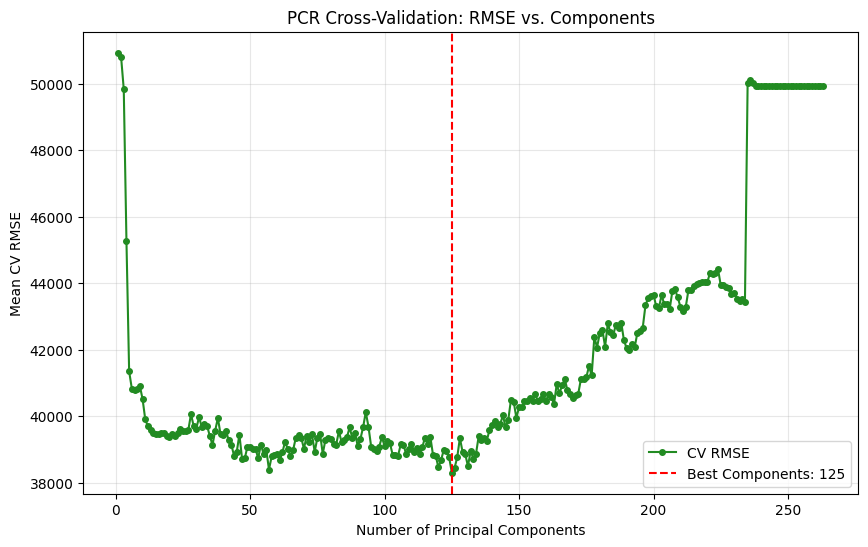

Optimal Components: 125
Test RMSE: 34931.2989


In [34]:
# Build PCR Pipeline
# PCR must include scaling because PCA is sensitive to the scale of features
pcr_pipe = Pipeline([
    ('pca', PCA()),
    ('regression', LinearRegression())
])

# Grid Search for Number of Components
# We test from 1 component up to the total number of features
param_grid = {'pca__n_components': np.arange(1, X.shape[1] + 1)}
pcr_grid = GridSearchCV(pcr_pipe, param_grid, cv=5, scoring='neg_mean_squared_error')
pcr_grid.fit(X_train_scaled, y_train)

# Extract RMSE Path
# GridSearchCV returns negative MSE; we negate and take the square root
mean_mse = -pcr_grid.cv_results_['mean_test_score']
rmse_path = np.sqrt(mean_mse)
components = param_grid['pca__n_components']

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(components, rmse_path, marker='o', markersize=4, color='forestgreen', label='CV RMSE')
plt.axvline(pcr_grid.best_params_['pca__n_components'], color='red', linestyle='--', 
            label=f"Best Components: {pcr_grid.best_params_['pca__n_components']}")

plt.xlabel('Number of Principal Components')
plt.ylabel('Mean CV RMSE')
plt.title('PCR Cross-Validation: RMSE vs. Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal Components: {pcr_grid.best_params_['pca__n_components']}")
y_preds = pcr_grid.predict(X_test_scaled)
# Inverse transform back to dollar scale
pcr_preds_dollars = convert_to_dollars(y_preds, lam, 0)
pcr_rmse = np.sqrt(mean_squared_error(y_test_original, pcr_preds_dollars))
print(f"Test RMSE: {pcr_rmse:.4f}")

# PLS

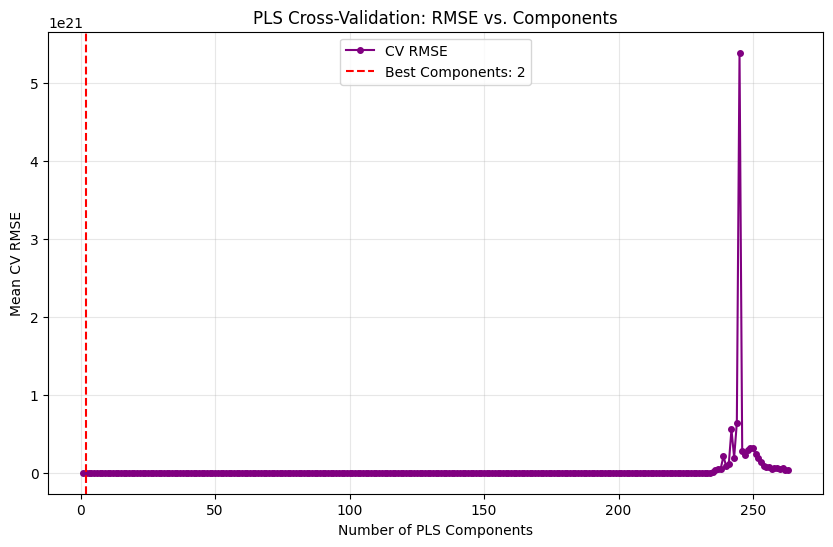

Optimal Components: 2
Test RMSE: 34205.3990


In [35]:
# Build PLS Pipeline
# Even though PLS scales internally, using StandardScaler in a Pipeline is best practice
pls_pipe = Pipeline([
    ('pls', PLSRegression())
])

# Grid Search for Number of Components
# We test from 1 component up to the total number of features
param_grid = {'pls__n_components': np.arange(1, X.shape[1] + 1)}
pls_grid = GridSearchCV(pls_pipe, param_grid, cv=5, scoring='neg_mean_squared_error')
pls_grid.fit(X_train_scaled, y_train)

# Extract RMSE Path
mean_mse = -pls_grid.cv_results_['mean_test_score']
rmse_path = np.sqrt(mean_mse)
components = param_grid['pls__n_components']

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(components, rmse_path, marker='o', markersize=4, color='purple', label='CV RMSE')
plt.axvline(pls_grid.best_params_['pls__n_components'], color='red', linestyle='--', 
            label=f"Best Components: {pls_grid.best_params_['pls__n_components']}")

plt.xlabel('Number of PLS Components')
plt.ylabel('Mean CV RMSE')
plt.title('PLS Cross-Validation: RMSE vs. Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal Components: {pls_grid.best_params_['pls__n_components']}")
y_preds = pls_grid.predict(X_test_scaled)
# Inverse transform back to dollar scale
pls_preds_dollars = convert_to_dollars(y_preds, lam, 0)
pls_rmse = np.sqrt(mean_squared_error(y_test_original, pls_preds_dollars))
print(f"Test RMSE: {pls_rmse:.4f}")

# Model Summaries

In [36]:
print(f"OLS RMSE: {ols_rmse:.4f}")
print(f"Lasso RMSE: {lasso_rmse:.4f}")
print(f"Ridge RMSE: {ridge_rmse:.4f}")
print(f"PCR RMSE: {pcr_rmse:.4f}")
print(f"PLS RMSE: {pls_rmse:.4f}")

OLS RMSE: 82096.4446
Lasso RMSE: 32992.5927
Ridge RMSE: 36111.1962
PCR RMSE: 34931.2989
PLS RMSE: 34205.3990


# Model Analysis

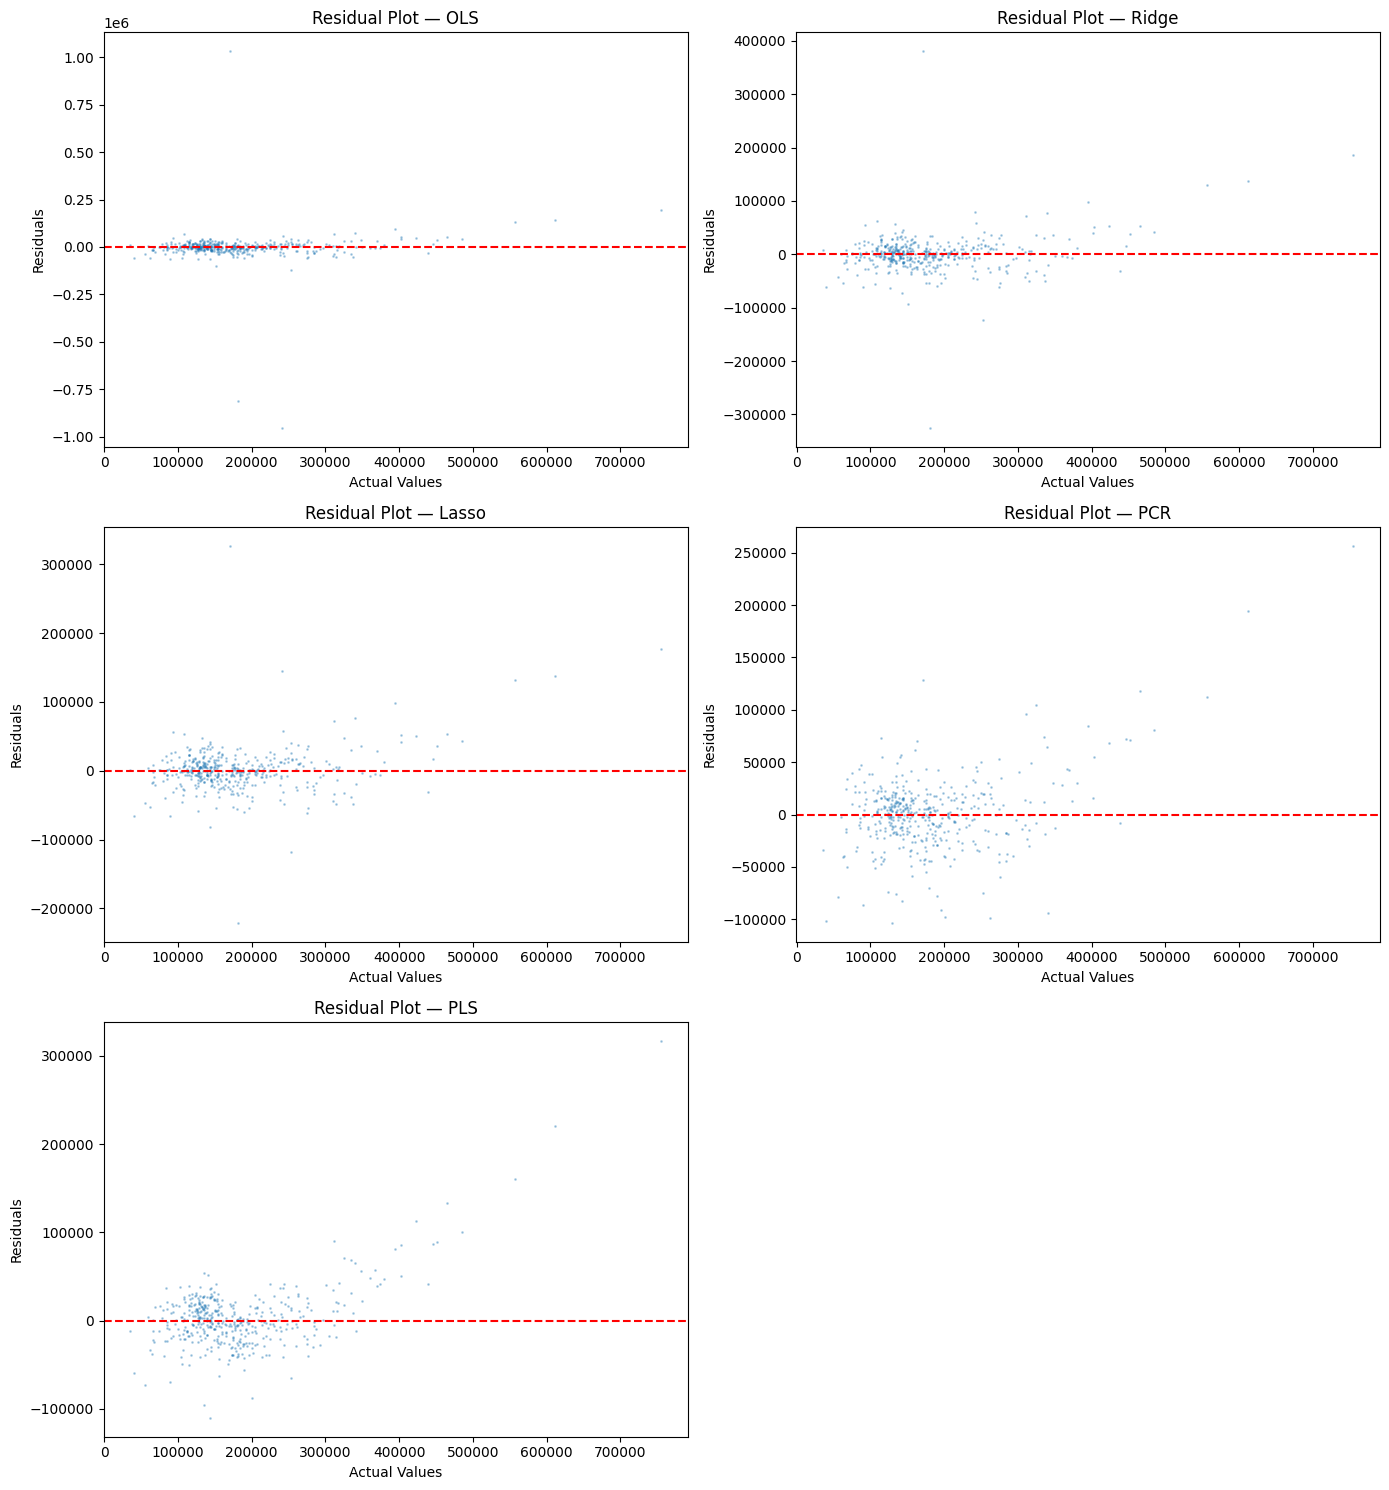

In [38]:
# Store predictions for each model
models = {
    'OLS': ols_preds_dollars,
    'Ridge': rcv_preds_dollars,
    'Lasso': lcv_preds_dollars,
    'PCR': pcr_preds_dollars,
    'PLS': pls_preds_dollars
}

# Plot residuals for all models
plots_per_row = 2
rows = math.ceil(len(models) / plots_per_row)
plt.figure(figsize=(14, rows * 5))

for i, (name, preds) in enumerate(models.items(), 1):
    residuals = y_test_original - preds
    plt.subplot(rows, plots_per_row, i)
    plt.scatter(y_test_original, residuals, alpha=0.3, s=1)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Actual Values')
    plt.ylabel('Residuals')
    plt.title(f'Residual Plot — {name}')

plt.tight_layout()
plt.show()